In [1]:
from pathlib import Path
import sys

sys.path.append(r"D:\Users\Hannes\Documents\Python Code\nRTD\lib")

import wandb
from wandb_util import extract_run_savepoint
from nRTD.rtd_fitting import RTDModule, RTDDataModule

import matplotlib.pyplot as plt
import matplotlib as mpl
import ICIW_Plots
import numpy as np
import torch


plt.style.use(["ICIWstyle"])
plt.rcParams.update(
    {
        "font.size": 7,
    }
)

In [2]:
# run_id = "jkwy4zpw" # with the shorter kernel times
run_id = "nx6hue2t"
name, ckpt_path = extract_run_savepoint(f"ice_ulm/HSA_MGA_nRTD/{run_id}")
model = RTDModule.load_from_checkpoint(ckpt_path)
# model.net.conv_layers[0].set_to_direct_response()

E1 = model.net.E[0].numpy()
E2 = model.net.E[1].numpy()
E3 = model.net.E[2].numpy()
E4 = model.net.E[3].numpy()
t1 = model.net.conv_layers[0].t_kernel.detach().numpy()
t2 = model.net.conv_layers[1].t_kernel.detach().numpy()
t3 = model.net.conv_layers[2].t_kernel.detach().numpy()
t4 = model.net.conv_layers[3].t_kernel.detach().numpy()
delta_t = model.net.delta_t[0].item()
print(delta_t)

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb:   1 of 1 files downloaded.  


0.25


In [3]:
np.savez(
    "Es_30mlmin_1bar.npz",
    t1=t1,
    E1=E1,
    t2=t2,
    E2=E2,
    t3=t3,
    E3=E3,
    t4=t4,
    E4=E4,
)

In [4]:
print(I1 := np.trapz(E1, t1) + 1 / 2 * E1[0] * delta_t + 1 / 2 * E1[-1] * delta_t)
print(I2 := np.trapz(E2, t2) + 1 / 2 * E2[0] * delta_t + 1 / 2 * E2[-1] * delta_t)
print(I3 := np.trapz(E3, t3) + 1 / 2 * E3[0] * delta_t + 1 / 2 * E3[-1] * delta_t)
print(I4 := np.trapz(E4, t4) + 1 / 2 * E4[0] * delta_t + 1 / 2 * E4[-1] * delta_t)


print(I1 * I2 * I3 * I4)

1.0038151494882186
0.9990526870824397
0.9993832861073315
0.9981083869934082
1.000349881050215


In [5]:
dummy_I1 = I1 - E1[0] * delta_t
dummy_I2 = I2 - E2[0] * delta_t
dummy_I3 = I3 - E3[0] * delta_t
dummy_I4 = I4 - E4[0] * delta_t

print(dummy_I1)
print(dummy_I2)
print(dummy_I3)
print(dummy_I4)

1.003576944982342
0.9296250850893557
0.6108346437104046
0.9981083869934082


In [6]:
from scipy.integrate import simpson

tau_1 = simpson(t1 * E1 / dummy_I1, x=t1)
tau_2 = simpson(t2 * E2 / dummy_I2, x=t2)
tau_3 = simpson(t3 * E3 / dummy_I3, x=t3)
tau_4 = simpson(t4 * E4 / dummy_I4, x=t4)
print(f"{tau_1:.2f}")
print(f"{tau_2:.2f}")
print(f"{tau_3:.2f}")
print(f"{tau_4:.2f}")

6.12
13.89
2.82
2.26


In [7]:
sigma_1 = simpson((t1 - tau_1) ** 2 * E1, x=t1)
sigma_2 = simpson((t2 - tau_2) ** 2 * E2, x=t2)
sigma_3 = simpson((t3 - tau_3) ** 2 * E3, x=t3)
sigma_4 = simpson((t4 - tau_4) ** 2 * E4, x=t4)

print(f"{sigma_1:.2f}")
print(f"{sigma_2:.2f}")
print(f"{sigma_3:.2f}")
print(f"{sigma_4:.2f}")

8.70
28.84
1.67
4.85


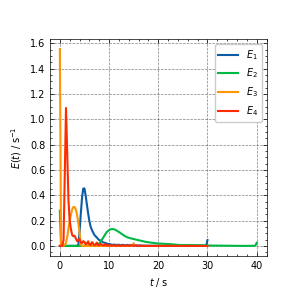

In [8]:
fig = ICIW_Plots.figure()
ax = ICIW_Plots.make_square_ax(
    fig,
    ax_width=5.5 * ICIW_Plots.cm2inch,
    left_h=0.5,
    xlabel=r"$t \;/\; \mathrm{s}$",
    ylabel=r"$E(t)\;/\;\mathrm{s}^{-1}$",
)
ax.plot(t1, E1, label="$E_1$")
ax.plot(t2, E2, label="$E_2$")
ax.plot(t3, E3, label="$E_3$")
ax.plot(t4, E4, label="$E_4$")
ax.legend()

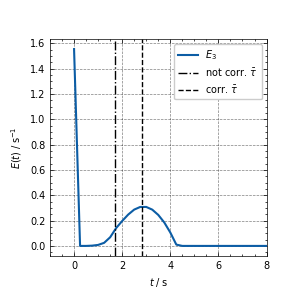

In [9]:
fig = ICIW_Plots.figure()
ax = ICIW_Plots.make_square_ax(
    fig,
    ax_width=5.5 * ICIW_Plots.cm2inch,
    left_h=0.5,
    xlabel=r"$t \;/\; \mathrm{s}$",
    ylabel=r"$E(t)\;/\;\mathrm{s}^{-1}$",
    xlim=(-1, 8),
    # ylim=(-0.05, 0.65),
)
# ax.plot(t1, E1, label="$E_1$")
# ax.plot(t2, E2, label="$E_2$")
ax.plot(t3, E3, label="$E_3$")
# ax.plot(t4, E4, label="$E_4$")
ax.axvline(1.72, color="black", lw=1, ls="-.", label=r"not corr. $\bar{\tau}$")
ax.axvline(2.82, color="black", lw=1, ls="--", label=r"corr. $\bar{\tau}$")
ax.legend()

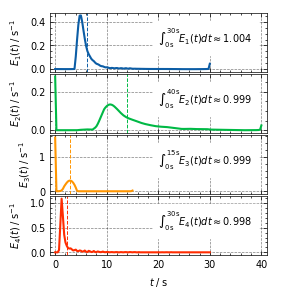

In [10]:
fig = ICIW_Plots.figure(height=7.5 * ICIW_Plots.cm2inch)
axs = ICIW_Plots.make_rect_subplots(
    fig,
    ax_width=5.5 * ICIW_Plots.cm2inch,
    ax_height=1.5 * ICIW_Plots.cm2inch,
    ax_layout=(4, 1),
    left_h=0.5,
    bottom_v=0.4,
    v_sep=0.02,
    xlabel=r"$t \;/\; \mathrm{s}$",
    ylabel=[
        r"$E_1(t)\;/\;\mathrm{s}^{-1}$",
        r"$E_2(t)\;/\;\mathrm{s}^{-1}$",
        r"$E_3(t)\;/\;\mathrm{s}^{-1}$",
        r"$E_4(t)\;/\;\mathrm{s}^{-1}$",
    ],
    xlim=(-1, 41),
    # ylim=(-0.05, 0.65),
)
axs[0, 0].plot(t1, E1, label="$E_1$", color="C0")
axs[0, 0].text(
    x=0.5,
    y=0.5,
    s=r"$\int_{0\mathrm{s}}^{30\mathrm{s}}E_1(t)dt \approx$" + f"{I1:.3f}",
    transform=axs[0, 0].transAxes,
    backgroundcolor="white",
)
axs[0, 0].axvline(x=tau_1, color="C0", linestyle="--", linewidth=0.7)
axs[1, 0].plot(t2, E2, label="$E_2$", color="C1")
axs[1, 0].text(
    x=0.5,
    y=0.5,
    s=r"$\int_{0\mathrm{s}}^{40\mathrm{s}}E_2(t)dt \approx$" + f"{I2:.3f}",
    transform=axs[1, 0].transAxes,
    backgroundcolor="white",
)
axs[1, 0].axvline(x=tau_2, color="C1", linestyle="--", linewidth=0.7)
axs[2, 0].plot(t3, E3, label="$E_3$", color="C2")
axs[2, 0].text(
    x=0.5,
    y=0.5,
    s=r"$\int_{0\mathrm{s}}^{15\mathrm{s}}E_3(t)dt \approx$" + f"{I3:.3f}",
    transform=axs[2, 0].transAxes,
    backgroundcolor="white",
)
axs[2, 0].axvline(x=tau_3, color="C2", linestyle="--", linewidth=0.7)
axs[3, 0].plot(t4, E4, label="$E_4$", color="C3")
axs[3, 0].text(
    x=0.5,
    y=0.5,
    s=r"$\int_{0\mathrm{s}}^{30\mathrm{s}}E_4(t)dt \approx$" + f"{I4:.3f}",
    transform=axs[3, 0].transAxes,
    backgroundcolor="white",
)
axs[3, 0].axvline(x=tau_4, color="C3", linestyle="--", linewidth=0.7)
# plt.savefig("all_Es_1bar.png", dpi=600)
# plt.savefig("all_Es_1bar.svg")

In [11]:
t_out = (0.0, 120.0)
t_in = (0.0, 5.0)
t_halfperiod = t_out[1] - t_out[0]
n_out = int(4 * (t_out[1] - t_out[0]) + 1)
n_in = int(4 * (t_in[1] - t_in[0]) + 1)
delta_t_out = (t_out[1] - t_out[0]) / (n_out - 1)
automated_switching_times = np.full((20,), t_halfperiod)
switching_times_total_system = np.insert(automated_switching_times, 0, 7.5 - 1.0)
switching_times_total_system = np.cumsum(switching_times_total_system)

data_total_system = RTDDataModule(
    batch_size=32,
    data_file=Path(
        r"D:\Users\Hannes\Documents\Python Code\nRTD\Experiments\HSA_004\data\MGA-E-10032025_30ml-min_1atm_TotalSystem.npz"
    ),
    switching_times=switching_times_total_system,
    t_range_in=t_in,
    n_in=n_in,
    t_range_out=t_out,
    n_out=n_out,
    switch_delay=1.0,
)

In [12]:
data_total_system.setup("eval")

True

In [13]:
print(data_total_system.x.shape)
print(data_total_system.t_in.shape)
data_total_system.y.shape

torch.Size([40, 1, 21])
torch.Size([40, 21])


torch.Size([40, 1, 481])

In [14]:
normalized_signals = (data_total_system.y - data_total_system.x[:, :, [0]]) / (
    data_total_system.x[:, :, [-1]] - data_total_system.x[:, :, [0]]
)
res = model(data_total_system.x.to(torch.float), data_total_system.t_in.to(torch.float))
normalized_res = (res[0] - data_total_system.x[:, :, [0]]) / (
    data_total_system.x[:, :, [-1]] - data_total_system.x[:, :, [0]]
)
print(data_total_system.y.shape)
print(normalized_signals.shape)

torch.Size([40, 1, 481])
torch.Size([40, 1, 481])


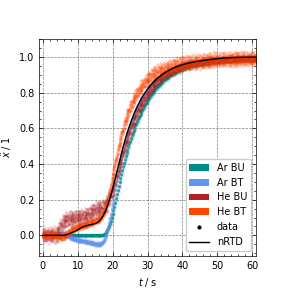

In [ ]:
fig = ICIW_Plots.figure(layout="single_column")
ax = ICIW_Plots.make_square_ax(
    fig,
    ax_width=5.5 * ICIW_Plots.cm2inch,
    xlabel=r"$t \;/\; \mathrm{s}$",
    ylabel=r"$\hat{x} \;/\; 1$",
)
ax.scatter(
    data_total_system.t_out[::4, ...],
    normalized_signals[::4, ...],
    alpha=0.1,
    s=2,
    label=r"Ar BU",
    color="darkcyan",
)
ax.scatter(
    data_total_system.t_out[2::4, ...],
    normalized_signals[2::4, ...],
    alpha=0.1,
    s=2,
    label=r"He BU",
    color="cornflowerblue",
)
ax.scatter(
    data_total_system.t_out[1::4, ...],
    normalized_signals[1::4, ...],
    alpha=0.1,
    s=2,
    label=r"Ar BT",
    color="firebrick",
)
ax.scatter(
    data_total_system.t_out[3::4, ...],
    normalized_signals[3::4, ...],
    alpha=0.1,
    s=2,
    label=r"He BT",
    color="orangered",
)
ax.plot(
    res[1][0, ...].detach().numpy(),
    normalized_res[0, 0, :].detach().numpy(),
    # lw=0,
    color="black",
    label="nRTD",
    lw=1,
)
legend_handles = [
    mpl.patches.Patch(facecolor="darkcyan"),
    mpl.patches.Patch(facecolor="cornflowerblue"),
    mpl.patches.Patch(facecolor="firebrick"),
    mpl.patches.Patch(facecolor="orangered"),
    plt.Line2D([0], [0], color="None", marker="o", markerfacecolor="k", markersize=2),
    plt.Line2D([0], [0], color="k", lw=1),
]
legend_names = [
    r"Ar BU",
    r"Ar BT",
    r"He BU",
    r"He BT",
    r"data",
    r"nRTD",
]

ax.set_xlim(-1, 61)

ax.legend(legend_handles, legend_names, loc="lower right")
# plt.savefig("norm_exp_data_1bar_inone.png", dpi=600)
# plt.savefig("norm_exp_data_1bar_inone.svg")

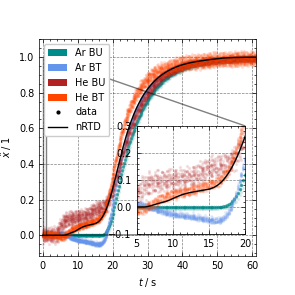

In [ ]:
fig = ICIW_Plots.figure(layout="single_column")
ax = ICIW_Plots.make_square_ax(
    fig,
    ax_width=5.5 * ICIW_Plots.cm2inch,
    xlabel=r"$t \;/\; \mathrm{s}$",
    ylabel=r"$\hat{x} \;/\; 1$",
)
ax.scatter(
    data_total_system.t_out[::4, ...],
    normalized_signals[::4, ...],
    alpha=0.1,
    s=2,
    label=r"Ar BU",
    color="darkcyan",
)
ax.scatter(
    data_total_system.t_out[2::4, ...],
    normalized_signals[2::4, ...],
    alpha=0.1,
    s=2,
    label=r"He BU",
    color="cornflowerblue",
)
ax.scatter(
    data_total_system.t_out[1::4, ...],
    normalized_signals[1::4, ...],
    alpha=0.1,
    s=2,
    label=r"Ar BT",
    color="firebrick",
)
ax.scatter(
    data_total_system.t_out[3::4, ...],
    normalized_signals[3::4, ...],
    alpha=0.1,
    s=2,
    label=r"He BT",
    color="orangered",
)
ax.plot(
    res[1][0, ...].detach().numpy(),
    normalized_res[0, 0, :].detach().numpy(),
    # lw=0,
    color="black",
    label="nRTD",
    lw=1,
)
legend_handles = [
    mpl.patches.Patch(facecolor="darkcyan"),
    mpl.patches.Patch(facecolor="cornflowerblue"),
    mpl.patches.Patch(facecolor="firebrick"),
    mpl.patches.Patch(facecolor="orangered"),
    plt.Line2D([0], [0], color="None", marker="o", markerfacecolor="k", markersize=2),
    plt.Line2D([0], [0], color="k", lw=1),
]
legend_names = [
    r"Ar BU",
    r"Ar BT",
    r"He BU",
    r"He BT",
    r"data",
    r"nRTD",
]

ax.set_xlim(-1, 61)

# make an inset axis for the first 20 seconds
inset_ax = ax.inset_axes(
    [0.45, 0.1, 0.5, 0.5],
    xlim=(5, 20),
    ylim=(-0.1, 0.3),
)  # [x, y, width, height]
# indicate the zoomed area
ax.indicate_inset_zoom(
    inset_ax,
    edgecolor="black",
    lw=1,
    linestyle="-",
)

inset_ax.scatter(
    data_total_system.t_out[::4, ...],
    normalized_signals[::4, ...],
    alpha=0.1,
    s=2,
    label=r"Ar BU",
    color="darkcyan",
)
inset_ax.scatter(
    data_total_system.t_out[2::4, ...],
    normalized_signals[2::4, ...],
    alpha=0.1,
    s=2,
    label=r"He BU",
    color="cornflowerblue",
)
inset_ax.scatter(
    data_total_system.t_out[1::4, ...],
    normalized_signals[1::4, ...],
    alpha=0.1,
    s=2,
    label=r"Ar BT",
    color="firebrick",
)
inset_ax.scatter(
    data_total_system.t_out[3::4, ...],
    normalized_signals[3::4, ...],
    alpha=0.1,
    s=2,
    label=r"He BT",
    color="orangered",
)
inset_ax.plot(
    res[1][0, ...].detach().numpy(),
    normalized_res[0, 0, :].detach().numpy(),
    # lw=0,
    color="black",
    label="nRTD",
    lw=1,
)


ax.legend(legend_handles, legend_names, loc="upper left")

In [16]:
t_in = torch.linspace(0, 300, 1201)
x_in = torch.zeros_like(t_in)
x_in[8:250] = 0.5
x_in[250:1180] = torch.sin(t_in[0 : 1180 - 250] / 10) * 0.2 + 0.5

print(x_in.reshape(1, 1, -1).shape)
print(t_in.reshape(1, -1).shape)

torch.Size([1, 1, 1201])
torch.Size([1, 1201])


In [17]:
res = model(x_in.reshape(1, 1, -1), t_in.reshape(1, -1))

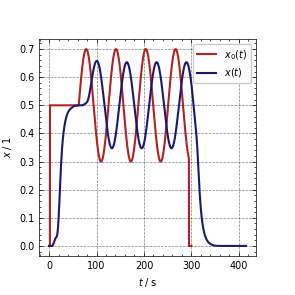

In [18]:
fig = ICIW_Plots.figure(layout="single_column")
ax = ICIW_Plots.make_square_ax(
    fig,
    ax_width=5.5 * ICIW_Plots.cm2inch,
    # left_h=0.5,
    xlabel=r"$t \;/\; \mathrm{s}$",
    ylabel=r"$x \;/\; 1$",
)
ax.plot(
    t_in,
    x_in,
    color="firebrick",
    label="$x_0(t)$",
)
ax.plot(
    res[1].detach().numpy().squeeze(),
    res[0].detach().numpy().squeeze(),
    label="$x(t)$",
    color="midnightblue",
)
ax.legend()
plt.savefig("example_arbitrary_input.png", dpi=600)

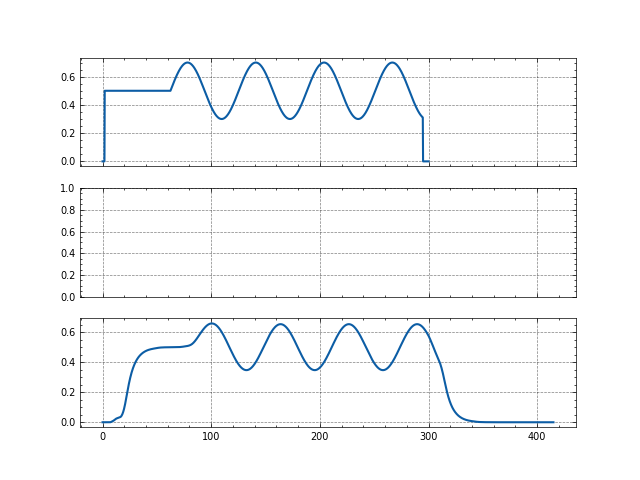

In [ ]:
fix, axs = plt.subplots(3, 1, sharex=True)

axs[0].plot(t_in, x_in)

axs[2].plot(
    res[1].detach().numpy().squeeze(),
    res[0].detach().numpy().squeeze(),
)